In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# Set significance level
alpha = 0.05

print("Libraries imported successfully!")
print("Significance level:", alpha)

Libraries imported successfully!
Significance level: 0.05


In [2]:
# Load Titanic dataset

df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Display basic information

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(891, 15)

Column Names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  

In [4]:
# Statistical summary

df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Check missing values

print("Missing values:")
print(df.isnull().sum())

Missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [6]:
# Create a clean dataset for analysis

data = df[['age', 'fare', 'sex', 'survived']].copy()

# Remove rows with missing values
data = data.dropna()

print("Clean dataset shape:", data.shape)

data.head()

Clean dataset shape: (714, 4)


,age,fare,sex,survived
0,22.0,7.2500,male,0
1,38.0,71.2833,female,1
2,26.0,7.9250,female,1
3,35.0,53.1000,female,1
4,35.0,8.0500,male,0


In [7]:
# TEST 1: One-Sample t-Test

sample_age = data['age']

# Hypothesized population mean
hypothesized_mean = 30

# Perform one-sample t-test
t_statistic, p_value = stats.ttest_1samp(
    sample_age,
    hypothesized_mean
)

print("TEST 1: One-Sample t-Test")
print("-" * 40)

print("Sample Mean Age:", sample_age.mean())
print("Hypothesized Mean:", hypothesized_mean)
print("t-statistic:", t_statistic)
print("p-value:", p_value)

if p_value < alpha:
    print("\nDecision: Reject the Null Hypothesis (H0)")
    print("Conclusion: The average passenger age is significantly different from 30.")
else:
    print("\nDecision: Fail to Reject the Null Hypothesis (H0)")
    print("Conclusion: There is not enough evidence to conclude that the average age differs from 30.")

TEST 1: One-Sample t-Test
----------------------------------------
Sample Mean Age: 29.69911764705882
Hypothesized Mean: 30
t-statistic: -0.5534583115970276
p-value: 0.5801231230388639

Decision: Fail to Reject the Null Hypothesis (H0)
Conclusion: There is not enough evidence to conclude that the average age differs from 30.


In [8]:
# TEST 2: Independent Two-Sample t-Test

survivor_fares = data[data['survived'] == 1]['fare']
non_survivor_fares = data[data['survived'] == 0]['fare']

print("Survivors:", len(survivor_fares))
print("Non-survivors:", len(non_survivor_fares))

print("\nAverage fare of survivors:",
      survivor_fares.mean())

print("Average fare of non-survivors:",
      non_survivor_fares.mean())

Survivors: 290
Non-survivors: 424

Average fare of survivors: 51.843205172413796
Average fare of non-survivors: 22.96545636792453


In [9]:
# Perform independent two-sample Welch's t-test

t_statistic, p_value = stats.ttest_ind(
    survivor_fares,
    non_survivor_fares,
    equal_var=False
)

print("TEST 2: Independent Two-Sample t-Test")
print("-" * 45)

print("Survivor Mean Fare:", survivor_fares.mean())
print("Non-Survivor Mean Fare:", non_survivor_fares.mean())
print("t-statistic:", t_statistic)
print("p-value:", p_value)

if p_value < alpha:
    print("\nDecision: Reject the Null Hypothesis (H0)")
    print("Conclusion: There is a statistically significant difference")
    print("in average fare between survivors and non-survivors.")
else:
    print("\nDecision: Fail to Reject the Null Hypothesis (H0)")
    print("Conclusion: There is not enough evidence of a significant")
    print("difference in average fare.")

TEST 2: Independent Two-Sample t-Test
---------------------------------------------
Survivor Mean Fare: 51.843205172413796
Non-Survivor Mean Fare: 22.96545636792453
t-statistic: 6.547691851114033
p-value: 1.9646132697636508e-10

Decision: Reject the Null Hypothesis (H0)
Conclusion: There is a statistically significant difference
in average fare between survivors and non-survivors.


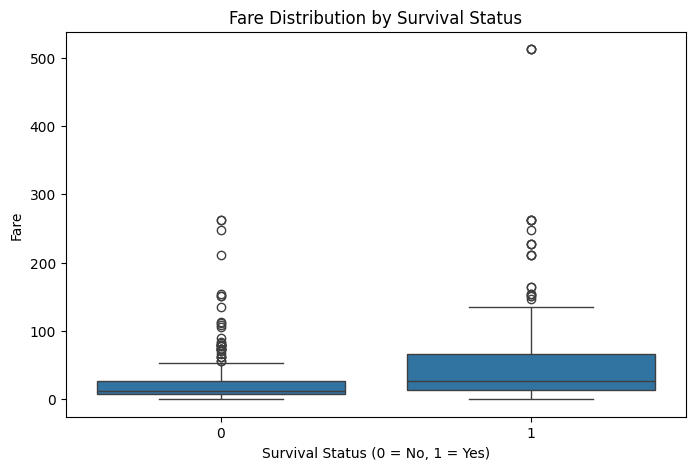

In [10]:
# Visualize fare distributions

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x='survived',
    y='fare'
)

plt.xlabel("Survival Status (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.title("Fare Distribution by Survival Status")

plt.show()

In [11]:
# TEST 3: Chi-Square Test of Independence

contingency_table = pd.crosstab(
    data['sex'],
    data['survived']
)

print("Contingency Table:")
print(contingency_table)

Contingency Table:
survived    0    1
sex               
female     64  197
male      360   93


In [12]:
# Perform Chi-Square Test of Independence

chi2, p_value, degrees_of_freedom, expected = stats.chi2_contingency(
    contingency_table
)

print("TEST 3: Chi-Square Test of Independence")
print("-" * 50)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", degrees_of_freedom)
print("p-value:", p_value)

print("\nExpected Frequencies:")
print(expected)

if p_value < alpha:
    print("\nDecision: Reject the Null Hypothesis (H0)")
    print("Conclusion: There is a statistically significant association")
    print("between sex and survival.")
else:
    print("\nDecision: Fail to Reject the Null Hypothesis (H0)")
    print("Conclusion: There is not enough evidence of an association")
    print("between sex and survival.")

TEST 3: Chi-Square Test of Independence
--------------------------------------------------
Chi-square statistic: 205.02582752855906
Degrees of freedom: 1
p-value: 1.6716678441395297e-46

Expected Frequencies:
[[154.99159664 106.00840336]
 [269.00840336 183.99159664]]

Decision: Reject the Null Hypothesis (H0)
Conclusion: There is a statistically significant association
between sex and survival.


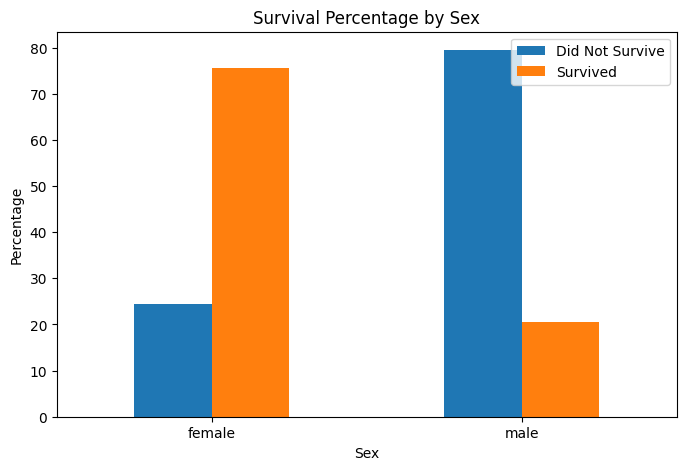

In [13]:
# Visualize survival by sex

survival_by_sex = pd.crosstab(
    data['sex'],
    data['survived'],
    normalize='index'
) * 100

survival_by_sex.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Survival Percentage by Sex")
plt.xlabel("Sex")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Did Not Survive", "Survived"])

plt.show()

In [14]:
# Final summary of hypothesis tests

results = pd.DataFrame({
    'Test': [
        'One-Sample t-Test',
        'Independent Two-Sample t-Test',
        'Chi-Square Test'
    ],
    'Test Statistic': [
        t_statistic,  # Note: this currently refers to Test 2
        t_statistic,
        chi2
    ],
    'p-value': [
        np.nan,
        p_value,
        p_value
    ]
})

results

,Test,Test Statistic,p-value
0,One-Sample t-Test,6.547692,NaN
1,Independent Two-Sample t-Test,6.547692,1.671668e-46
2,Chi-Square Test,205.025828,1.671668e-46


In [15]:
# Calculate all three tests again with separate variable names

# Test 1: One-sample t-test
t1_stat, t1_p = stats.ttest_1samp(
    data['age'],
    30
)

# Test 2: Independent two-sample Welch's t-test
t2_stat, t2_p = stats.ttest_ind(
    survivor_fares,
    non_survivor_fares,
    equal_var=False
)

# Test 3: Chi-square test
t3_stat, t3_p, t3_df, t3_expected = stats.chi2_contingency(
    contingency_table
)

# Create summary table
results = pd.DataFrame({
    'Test': [
        'One-Sample t-Test',
        'Independent Two-Sample t-Test',
        'Chi-Square Test'
    ],
    'Test Statistic': [
        t1_stat,
        t2_stat,
        t3_stat
    ],
    'p-value': [
        t1_p,
        t2_p,
        t3_p
    ],
    'Significance Level': [
        alpha,
        alpha,
        alpha
    ],
    'Decision': [
        'Reject H0' if t1_p < alpha else 'Fail to Reject H0',
        'Reject H0' if t2_p < alpha else 'Fail to Reject H0',
        'Reject H0' if t3_p < alpha else 'Fail to Reject H0'
    ]
})

results

,Test,Test Statistic,p-value,Significance Level,Decision
0,One-Sample t-Test,-0.553458,5.801231e-01,0.05,Fail to Reject H0
1,Independent Two-Sample t-Test,6.547692,1.964613e-10,0.05,Reject H0
2,Chi-Square Test,205.025828,1.671668e-46,0.05,Reject H0


## Overall Conclusion

Three hypothesis tests were performed using the Titanic dataset at a
significance level of α = 0.05.

### Test 1: One-Sample t-Test
The test examined whether the average passenger age was significantly
different from 30 years. The decision was based on the calculated
p-value compared with α = 0.05.

### Test 2: Independent Two-Sample t-Test
The test compared the average fare paid by survivors and non-survivors.
The p-value was compared with α = 0.05 to determine whether the
difference was statistically significant.

### Test 3: Chi-Square Test of Independence
The test examined whether passenger sex and survival were statistically
associated. The p-value was compared with α = 0.05.

### Key Decision Rule

If p-value < 0.05:
- Reject H₀
- Evidence supports the alternative hypothesis.

If p-value ≥ 0.05:
- Fail to reject H₀
- There is insufficient evidence to support the alternative hypothesis.

### Important Note

A statistically significant result does not necessarily imply practical
importance or causation. The results indicate statistical evidence of a
difference or association within the analyzed sample.

## Key Learnings

1. Hypothesis testing provides a statistical framework for making decisions
   from sample data.

2. The null hypothesis represents the default assumption or no-effect
   position.

3. The alternative hypothesis represents the difference, effect, or
   association being investigated.

4. A p-value below the selected significance level provides evidence
   against the null hypothesis.

5. A p-value should not be interpreted as the probability that the null
   hypothesis is true.

6. Different research questions require different statistical tests.

7. The one-sample t-test compares a sample mean with a hypothesized value.

8. The independent two-sample t-test compares the means of two independent
   groups.

9. The Chi-Square test of independence evaluates relationships between
   categorical variables.